In [1]:
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv(r"\Users\Anjli Kumari\datasets\titanic_toy.csv")
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [5]:
X = df.drop(columns=['Survived'])
Y = df['Survived']

In [5]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [6]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [7]:
X_train.isnull().mean()

Age       0.196629
Fare      0.050562
Family    0.000000
dtype: float64

In [8]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()
mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [9]:
X_train['Median_Age'] = X_train['Age'].fillna(median_age)
X_train['Mean_Age'] = X_train['Age'].fillna(mean_age)
X_train['Median_Fare'] = X_train['Fare'].fillna(median_fare)
X_train['Mean_Fare'] = X_train['Fare'].fillna(mean_fare)

In [10]:
X_train.sample(5)

,Age,Fare,Family,Median_Age,Mean_Age,Median_Fare,Mean_Fare
470,NaN,7.2500,0,28.0,29.498846,7.2500,7.2500
115,21.0,7.9250,0,21.0,21.000000,7.9250,7.9250
183,1.0,39.0000,3,1.0,1.000000,39.0000,39.0000
601,NaN,7.8958,0,28.0,29.498846,7.8958,7.8958
164,1.0,39.6875,5,1.0,1.000000,39.6875,39.6875


In [11]:
print("Original Age Variable Variance:" , X_train['Age'].var())
print("Age Variance After Median Imputation:" , X_train['Median_Age'].var())
print("Age Variance After Mean Imputation:" , X_train['Mean_Age'].var())

print("Original Fare Variable Variance:" , X_train['Fare'].var())
print("Fare Variance After Median Imputation:" , X_train['Median_Fare'].var())
print("Fare Variance After Mean Imputation:" , X_train['Mean_Fare'].var())

Original Age Variable Variance: 210.2517072477435
Age Variance After Median Imputation: 169.20731007048155
Age Variance After Mean Imputation: 168.85193366872227
Original Fare Variable Variance: 2761.0314349486343
Fare Variance After Median Imputation: 2637.012481677765
Fare Variance After Mean Imputation: 2621.232374951235


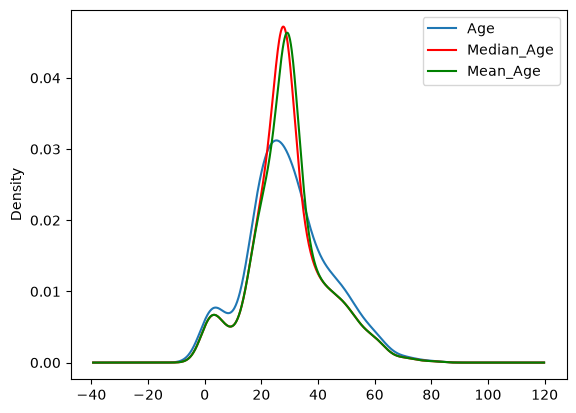

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)
X_train['Age'].plot(kind='kde',ax=ax)
X_train['Median_Age'].plot(kind='kde',ax=ax,color='Red')
X_train['Mean_Age'].plot(kind='kde',ax=ax,color='Green')
lines , labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

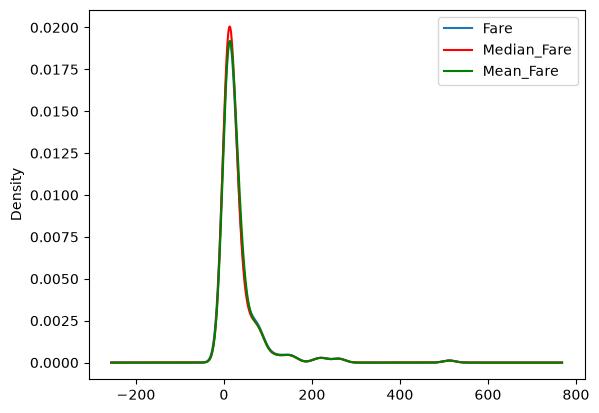

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)
X_train['Fare'].plot(kind='kde',ax=ax)
X_train['Median_Fare'].plot(kind='kde',ax=ax,color='Red')
X_train['Mean_Fare'].plot(kind='kde',ax=ax,color='Green')
lines , labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [14]:
X_train.cov()

,Age,Fare,Family,Median_Age,Mean_Age,Median_Fare,Mean_Fare
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,70.082085,71.193767
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.672035,17.657433
Median_Age,210.251707,63.938058,-5.587710,169.207310,168.851934,59.728510,60.700688
Mean_Age,210.251707,60.224654,-5.616299,168.851934,168.851934,56.282518,57.175304
Median_Fare,70.082085,2761.031435,17.672035,59.728510,56.282518,2637.012482,2621.232375
Mean_Fare,71.193767,2761.031435,17.657433,60.700688,57.175304,2621.232375,2621.232375


In [15]:
X_train.corr()

,Age,Fare,Family,Median_Age,Mean_Age,Median_Fare,Mean_Fare
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.087232,0.088944
Fare,0.091482,1.000000,0.207193,0.093496,0.088151,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.255307,-0.256883,0.204536,0.204981
Median_Age,1.000000,0.093496,-0.255307,1.000000,0.998949,0.089416,0.091145
Mean_Age,1.000000,0.088151,-0.256883,0.998949,1.000000,0.084346,0.085941
Median_Fare,0.087232,1.000000,0.204536,0.089416,0.084346,1.000000,0.997003
Mean_Fare,0.088944,1.000000,0.204981,0.091145,0.085941,0.997003,1.000000


<Axes: >

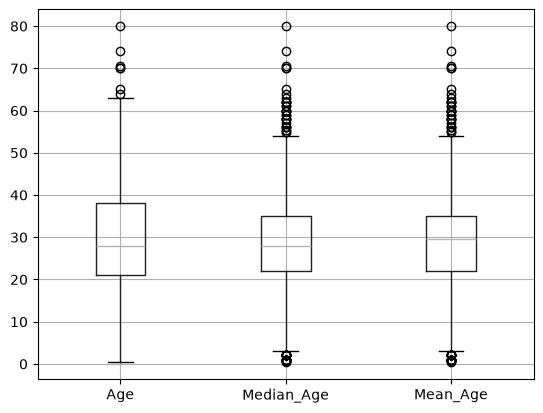

In [16]:
X_train[['Age','Median_Age','Mean_Age']].boxplot()

<Axes: >

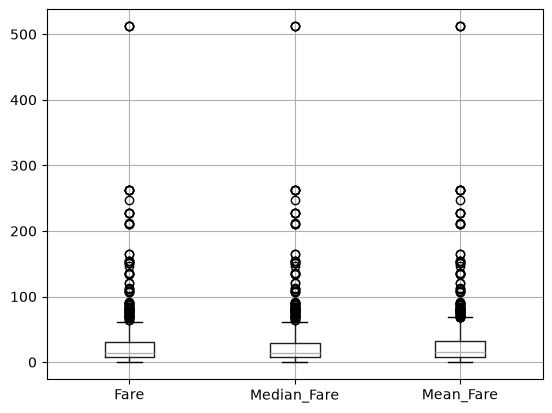

In [17]:
X_train[['Fare','Median_Fare','Mean_Fare']].boxplot()

In [6]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,2)

In [22]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [24]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare']),
],remainder='passthrough')

In [25]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [26]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [27]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [28]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [29]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))

### Arbitrary-Value-Imputer

In [1]:
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv(r"\Users\Anjli Kumari\datasets\titanic_toy.csv")
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [7]:
X_train['Arb_Age1'] = X_train['Age'].fillna(99)
X_train['Arb_Age2'] = X_train['Age'].fillna(-1)
X_train['Arb_Fare1'] = X_train['Fare'].fillna(999)
X_train['Arb_Fare2'] = X_train['Fare'].fillna(-1)

In [9]:
print("Original Age Variable Variance:" , X_train['Age'].var())
print("Age Variance After Positive Value Imputation:" , X_train['Arb_Age1'].var())
print("Age Variance After Negative Value Imputation:" , X_train['Arb_Age2'].var())

print("Original Fare Variable Variance:" , X_train['Fare'].var())
print("Fare Variance After Positive Value Imputation:" , X_train['Arb_Fare1'].var())
print("Fare Variance After Negative Value Imputation:" , X_train['Arb_Fare2'].var())

Original Age Variable Variance: 204.34951339046142
Age Variance After Positive Value Imputation: 951.7275570187188
Age Variance After Negative Value Imputation: 318.0896202624488
Original Fare Variable Variance: 2448.1979137063163
Fare Variance After Positive Value Imputation: 47219.202652176304
Fare Variance After Negative Value Imputation: 2378.5676784883494


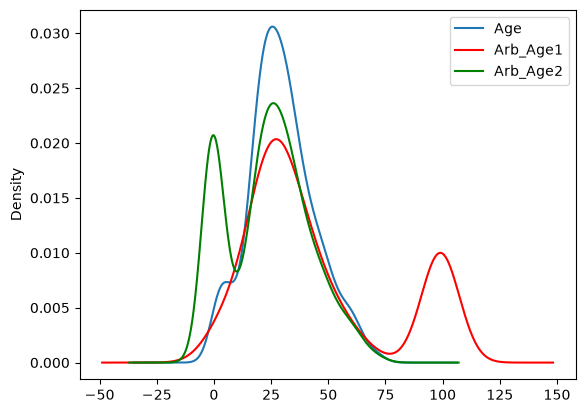

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111)
X_train['Age'].plot(kind='kde',ax=ax)
X_train['Arb_Age1'].plot(kind='kde',ax=ax,color='Red')
X_train['Arb_Age2'].plot(kind='kde',ax=ax,color='Green')
lines , labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

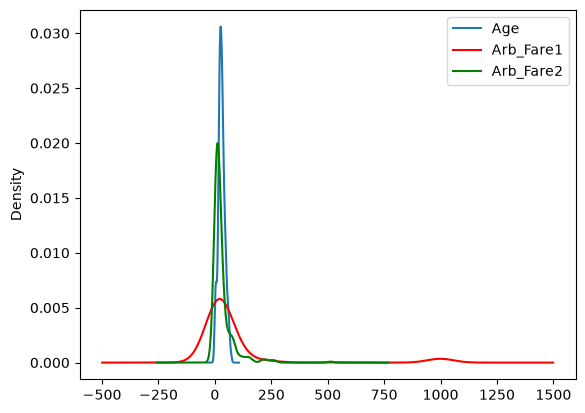

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)
X_train['Age'].plot(kind='kde',ax=ax)
X_train['Arb_Fare1'].plot(kind='kde',ax=ax,color='Red')
X_train['Arb_Fare2'].plot(kind='kde',ax=ax,color='Green')
lines , labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [12]:
X_train.cov()

,Age,Fare,Family,Arb_Age1,Arb_Age2,Arb_Fare1,Arb_Fare2
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,162.793430,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,11.528625,16.553989
Arb_Age1,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-159.931663,-94.317400
Arb_Age2,204.349513,125.558364,-4.149246,-189.535540,318.089620,257.379887,114.394141
Arb_Fare1,162.793430,2448.197914,11.528625,-159.931663,257.379887,47219.202652,762.474982
Arb_Fare2,63.321188,2448.197914,16.553989,-94.317400,114.394141,762.474982,2378.567678


In [13]:
X_train.corr()

,Age,Fare,Family,Arb_Age1,Arb_Age2,Arb_Fare1,Arb_Fare2
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.051179,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.032079,0.205233
Arb_Age1,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.023857,-0.062687
Arb_Age2,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.066411,0.131514
Arb_Fare1,0.051179,1.000000,0.032079,-0.023857,0.066411,1.000000,0.071946
Arb_Fare2,0.084585,1.000000,0.205233,-0.062687,0.131514,0.071946,1.000000


In [14]:
X_train,X_test,Y_train,Y_test = train(X,Y,0.2,42)

In [15]:
imputer1 = SimpleImputer(strategy='constant',fill_value=99)
imputer2 = SimpleImputer(strategy='constant',fill_value=999)

In [16]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare']),
],remainder='passthrough')

In [17]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [18]:
trf.named_transformers_['imputer1'].statistics_

array([99], dtype=object)

In [20]:
trf.named_transformers_['imputer2'].statistics_

array([999], dtype=object)

In [21]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [22]:
X_train


array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    , 999.    ,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]], shape=(712, 3))